# GRU - Gated Recurrent Unit (TensorFlow / Keras)

A GRU is a simplified alternative to the [`LSTM`](../07_LSTM): it merges the forget
and input gates into a single **update gate**, and drops the separate cell state,
using only the hidden state. Fewer parameters, often comparable accuracy, usually
faster to train.

Same task and pipeline as `06_RNN` / `07_LSTM` — newsgroup posts, **hockey vs. space**
(`sklearn.datasets.fetch_20newsgroups`) — only the recurrent layer changes,
from `LSTM` to `GRU`.

In [1]:
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

tf.random.set_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                           remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


train_tokens = [tokenize(doc) for doc in train.data]
test_tokens = [tokenize(doc) for doc in test.data]

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_tokens], dtype="int32")
X_test = np.array([encode(t) for t in test_tokens], dtype="int32")
y_train = train.target.astype("float32")
y_test = test.target.astype("float32")

vocab_size = len(vocab)
X_train.shape, vocab_size

((1193, 150), 5000)

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    tf.keras.layers.Embedding(vocab_size, 32, mask_zero=True),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,369 (649.88 KB)

 Trainable params: 166,369 (649.88 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30


 1/38 ━━━━━━━━━━━━━━━━━━━━ 36s 980ms/step - accuracy: 0.5312 - loss: 0.6923

 6/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5095 - loss: 0.6931  

11/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5175 - loss: 0.6919

16/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5273 - loss: 0.6883

...

24/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9825 - loss: 0.0173

28/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9831 - loss: 0.0171

32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9836 - loss: 0.0171

36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9839 - loss: 0.0172

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9866 - loss: 0.0186


Test accuracy: 0.897


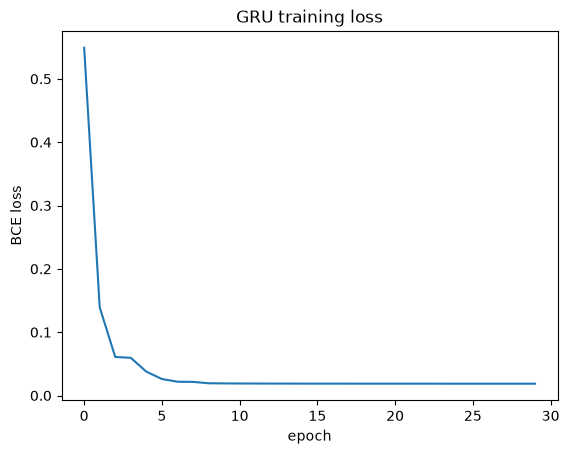

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("GRU training loss")
plt.show()